# Compare to Qudit LDPC Codes Paper

In [18]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.decoder import BPOSD, RelayBP
from bbq.simulation import process_results

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [ ]:
# Decoder setup

bposd_max_iter = 300
order = 0
osd_method = 'OSD_0'

relay_max_iter = 100
first_iter = 80
solutions = 1
relays = 10
centre = 0.125
width = 0.9


In [ ]:
field = Field(5)
x, y = Monomial(field, 'x'), Monomial(field, 'y')

# a, b = x + x**2, x**3 + 2*y + 2*y**2
# bb = BivariateBicycle(a, b, 4, 3, 1)

# a, b = 1 + y + x**2*y**2, 2 + x
# bb = BivariateBicycle(a, b, 5, 3, 1)

# a, b = 1 + 2*x, 1 + y + x**3*y**2
# bb = BivariateBicycle(a, b, 8, 3, 1)

# a, b = x**3 + 3*x**5 + 4, 3*x + 3*x**6 + 2*x**7 # not connected??
# bb = BivariateBicycle(a, b, 8, 4, 1)

# a, b = 3*x**6 + 3*x**2 + 4*x**3, x + 3*x**5 + 1  # not connected??
# bb = BivariateBicycle(a, b, 7, 2, 1)

# a, b = y**2 + 2*y**7 + 2*y**4, 3*y**6 + 3*y**3 + 4*y**8  # not connected??
# bb = BivariateBicycle(a, b, 3, 9, 1)

# a, b = 1 + y + x**2*y**2, 2 + 3*x
# bb = BivariateBicycle(a, b, 5, 3, 1)

a, b = 2 + 4*x, 3 + 3*y + x**3*y**2
bb = BivariateBicycle(a, b, 8, 3, 1)

# a, b = 4*x + 2*y + x**2, y**4 + 2*y**3 + 4*y**2
# bb = BivariateBicycle(a, b, 3, 5, 1)

hx, lx = bb.hx, bb.x_logicals
n_qudits = hx.shape[1]

print(bb)
print(len(lx))


Bivariate Bicycle code for
a(x, y) = 2 + 4x
b(x, y) = 3 + 3y + x^3y^2
4


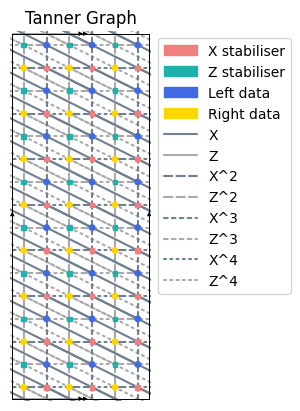

In [ ]:
bb.draw()


In [ ]:
# physical_error = np.logspace(-0.7, -3, 11)
physical_error = np.logspace(-0.7, -2.4, 11)[9:10]

num_failures = [5 for _ in range(11)]
results = []

print(f'Physical errors: {physical_error}')


Physical errors: [0.00588844]


In [194]:
res = []

for ind, p in enumerate(physical_error):
    print(f'Setting up error channel for p = {p}...')
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    # NOTE: sets mem_weight different for different powers of same qudit
    mem_weight = np.zeros((n_qudits, field.p, relays))
    mem_weight[:, :, 0] = centre
    mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))
    # mem_weight = np.zeros((n_qudits, field.p, relays))
    # mem_weight[:, :, 0] = centre
    # rand = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, relays - 1))
    # for i in range(0, field.p):
    #     mem_weight[:, i, 1:] = rand

    failures = 0
    num_trials = 0

    print('Starting trials...')
    while failures < num_failures[ind]:

        # Set up decoder
        decoder = RelayBP(field, hx, x_prior, max_iter=relay_max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
        # decoder = BPOSD(field, hx, x_prior, max_iter=bposd_max_iter, order=order)

        num_trials += 1

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        guessed_error, decoder_success, bp_success, posterior = decoder.decode(syndrome, metric=False, debug=True)
        error_difference = (error - guessed_error) % field.p

        logical_effect = (np.array(lx) @ error_difference) % field.p

        # Check success
        if np.any(logical_effect != 0):
            failures += 1

        # Update saved data
        if num_trials % 5000 == 0:
            print(f'UPDATE: p={p:.4f}, trials={num_trials}, failures={failures}')

    res.append(num_trials)

    print('Completed simulation!')
    print(f'p={p:.4f}, trials={num_trials}, failures={failures}')
    print(f'[{ind + 1}/{len(physical_error)}]')


Setting up error channel for p = 0.005888436553555896...
Starting trials...
UPDATE: p=0.0059, trials=5000, failures=0
UPDATE: p=0.0059, trials=10000, failures=0
UPDATE: p=0.0059, trials=15000, failures=0
UPDATE: p=0.0059, trials=20000, failures=0
UPDATE: p=0.0059, trials=25000, failures=0
UPDATE: p=0.0059, trials=30000, failures=0
UPDATE: p=0.0059, trials=35000, failures=0
UPDATE: p=0.0059, trials=40000, failures=1
UPDATE: p=0.0059, trials=45000, failures=1
UPDATE: p=0.0059, trials=50000, failures=1
UPDATE: p=0.0059, trials=55000, failures=1
UPDATE: p=0.0059, trials=60000, failures=1
UPDATE: p=0.0059, trials=65000, failures=1
UPDATE: p=0.0059, trials=70000, failures=1
UPDATE: p=0.0059, trials=75000, failures=1
UPDATE: p=0.0059, trials=80000, failures=1
UPDATE: p=0.0059, trials=85000, failures=1
UPDATE: p=0.0059, trials=90000, failures=1
UPDATE: p=0.0059, trials=95000, failures=1
UPDATE: p=0.0059, trials=100000, failures=1
UPDATE: p=0.0059, trials=105000, failures=1
UPDATE: p=0.0059, tr

In [ ]:
res[0] + 3155031


9978543

In [ ]:
results_relaybp = {}

results_relaybp[1] = [12, 23, 70, 223, 801, 1895, 5877, 17294, 16890, 107021, 479694]
results_relaybp[2] = [12, 26, 98, 415, 1922, 13615, 46031, 223347, 1549354]
results_relaybp[3] = [11, 28, 211, 2179, 9822, 80969, 682718, 3527236]

results_relaybp[4] = [13, 17, 29, 86, 200, 996, 2095, 10649, 31268, 102214, 192531]
results_relaybp[5] = [13, 21, 68, 130, 148, 1862, 2071, 10584, 25432, 44796, 245319]
results_relaybp[6] = [10, 19, 28, 143, 197, 662, 4609, 11117, 52194, 128769, 368089]
results_relaybp[7] = [17, 31, 84, 127, 699, 2806, 8418, 12679, 72244, 354804, 984809]
results_relaybp[8] = [17, 35, 133, 945, 5999, 23229, 197193, 521658, 4053136, 9978543]

# results_relaybp[9] = []
# results_relaybp[10] = []
# results_relaybp[11] = []


In [ ]:
results_bposd = {}
results_bposd[1] = [12, 24, 51, 146, 1018, 1792, 7076, 24302, 56029, 116993, 341904]
results_bposd[2] = [13, 26, 81, 213, 1046, 12016, 33638, 379000, 977844]
results_bposd[3] = [14, 68, 154, 1383, 6926, 62387, 526910, 3289343]


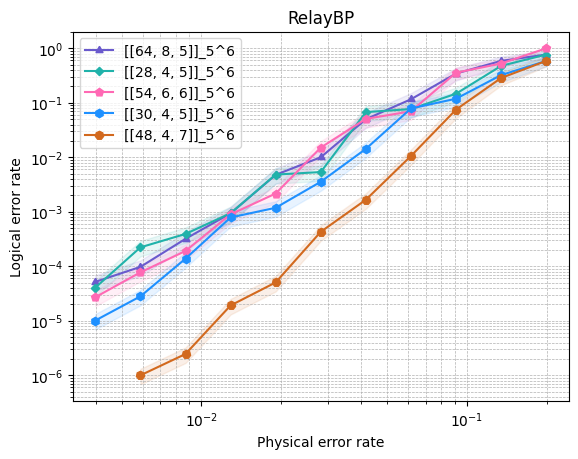

In [201]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='[[64, 8, 5]]_5^6'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='[[28, 4, 5]]_5^6'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='[[54, 6, 6]]_5^6'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='[[30, 4, 5]]_5^6'),
    Line2D([0], [0], color='chocolate', marker=(7, 0, 0), linestyle='-', label='[[48, 4, 7]]_5^6')
]

physical_error = np.logspace(-0.7, -2.4, 11)
plot_results, plot_errors = process_results(results_relaybp, {1:10, 2:10, 3:10, 4:10, 5:10, 6:10, 7:10, 8:10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[4], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[5], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[6], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[7], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error[0:10], plot_results[8], color='chocolate', marker=(7, 0, 0))
ax.fill_between(physical_error, plot_results[4] - plot_errors[4], plot_results[4] + plot_errors[4], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[5] - plot_errors[5], plot_results[5] + plot_errors[5], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[6] - plot_errors[6], plot_results[6] + plot_errors[6], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[7] - plot_errors[7], plot_results[7] + plot_errors[7], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error[0:10], plot_results[8] - plot_errors[8], plot_results[8] + plot_errors[8], color='chocolate', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('RelayBP');


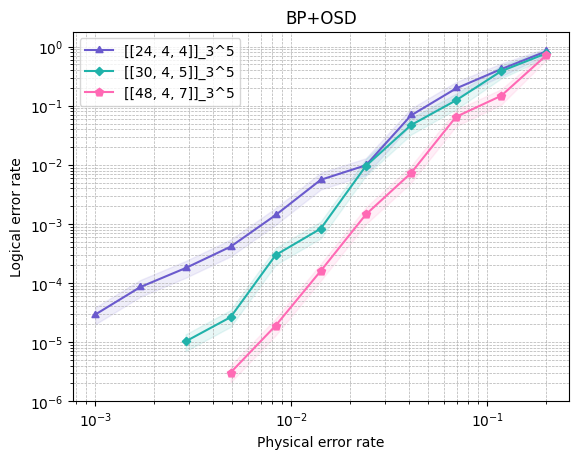

In [125]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='[[24, 4, 4]]_3^5'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='[[30, 4, 5]]_3^5'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='[[48, 4, 7]]_3^5')
]

physical_error = np.logspace(-0.7, -3, 11)
plot_results, plot_errors = process_results(results_bposd, {1:10, 2:10, 3:10, 4:10, 5:10, 6:10, 7:10, 8:10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error[0:9], plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error[0:8], plot_results[3][0:8], color='hotpink', marker=(5, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error[0:9], plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error[0:8], plot_results[3][0:8] - plot_errors[3][0:8], plot_results[3][0:8] + plot_errors[3][0:8], color='hotpink', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.set_ylim(10e-7)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('BP+OSD');


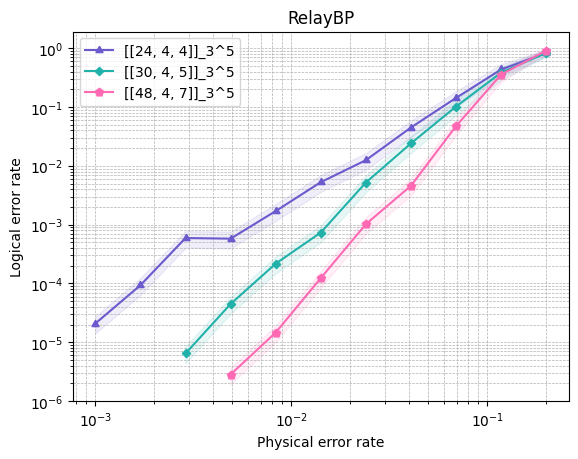

In [124]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='[[24, 4, 4]]_3^5'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='[[30, 4, 5]]_3^5'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='[[48, 4, 7]]_3^5')
]

physical_error = np.logspace(-0.7, -3, 11)
plot_results, plot_errors = process_results(results_relaybp, {1:10, 2:10, 3:10, 4:10, 5:10, 6:10, 7:10, 8:10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error[0:9], plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error[0:8], plot_results[3][0:8], color='hotpink', marker=(5, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error[0:9], plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error[0:8], plot_results[3][0:8] - plot_errors[3][0:8], plot_results[3][0:8] + plot_errors[3][0:8], color='hotpink', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.set_ylim(10e-7)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('RelayBP');
